In [22]:
#==========QUÁ TRÌNH EXPLANATORY DATA ANALYSYS============
#Đây lá quá trình khai thác thông tin tri thức từ dữ liệu thông qua biểu đồ. 
#Khi vẽ biểu đồ chúng ta cần đặt rá các câu hỏi
#1. Có bao nhiêu biến tham gia vào biểu đồ
#2. Loại (định tính, định lượng) của từng biến số
#3. Biểu đồ biểu diễn bao nhiêu thông tin
#4. Tri thức gì được rút trích ra từ biểu đồ
#5. Tri thức được rút trích có liên quan gì đến nghiệp vụ
#===========================================
#Bước 1: Xử lý dữ liệu cơ bản theo yêu cầu
#===========================================
#1.1. Đọc dữ liệu
#1.2. Loại bỏ dòng dữ liệu trống
#1.3. Loại bỏ dòng dữ liệu bị trùng
#1.4. Kiểm tra các dữ liệu thiếu bằng chart
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
#1.1. Đọc dữ liệu
#df = pd.read_csv('orginal_sales_data_edit.csv')
df =pd.read_csv('orginal_sales_data_edit.csv',encoding='utf-8', header=0,delimiter=',')

In [23]:
df
#Kết quả: 2824 dòng

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE,PAYMENTFULLNAME
0,10107,30,95.70,2,2871.00,2/24/2003,Shipped,1,2,2003,...,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small,Yu Kwai
1,10121,34,81.35,5,2765.90,5/7/2003,Shipped,2,5,2003,...,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small,Henriot Paul
2,10134,41,94.74,2,3884.34,7/1/2003,Shipped,3,7,2003,...,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium,DaCunha Daniel
3,10145,45,83.26,6,3746.70,8/25/2003,Shipped,3,8,2003,...,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium,Young Julie
4,10159,49,100.00,14,5205.27,10/10/2003,Shipped,4,10,2003,...,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium,Brown Julie
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,10350,20,100.00,15,2244.40,12/2/2004,Shipped,4,12,2004,...,NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Small,Freyre Diego
2819,10373,29,100.00,1,3978.51,1/31/2005,Shipped,1,1,2005,...,NaN,Oulu,NaN,90110,Finland,EMEA,Koskitalo,Pirkko,Medium,Koskitalo Pirkko
2820,10386,43,100.00,4,5417.57,3/1/2005,Resolved,1,3,2005,...,NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Medium,Freyre Diego
2821,10397,34,62.24,1,2116.16,3/28/2005,Shipped,1,3,2005,...,NaN,Toulouse,NaN,31000,France,EMEA,Roulet,Annette,Small,Roulet Annette


In [24]:
#1.2. Loại bỏ dòng dữ liệu rỗng
df.dropna(how='all', inplace=True)
df #2824 dòng

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE,PAYMENTFULLNAME
0,10107,30,95.70,2,2871.00,2/24/2003,Shipped,1,2,2003,...,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small,Yu Kwai
1,10121,34,81.35,5,2765.90,5/7/2003,Shipped,2,5,2003,...,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small,Henriot Paul
2,10134,41,94.74,2,3884.34,7/1/2003,Shipped,3,7,2003,...,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium,DaCunha Daniel
3,10145,45,83.26,6,3746.70,8/25/2003,Shipped,3,8,2003,...,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium,Young Julie
4,10159,49,100.00,14,5205.27,10/10/2003,Shipped,4,10,2003,...,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium,Brown Julie
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,10350,20,100.00,15,2244.40,12/2/2004,Shipped,4,12,2004,...,NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Small,Freyre Diego
2819,10373,29,100.00,1,3978.51,1/31/2005,Shipped,1,1,2005,...,NaN,Oulu,NaN,90110,Finland,EMEA,Koskitalo,Pirkko,Medium,Koskitalo Pirkko
2820,10386,43,100.00,4,5417.57,3/1/2005,Resolved,1,3,2005,...,NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Medium,Freyre Diego
2821,10397,34,62.24,1,2116.16,3/28/2005,Shipped,1,3,2005,...,NaN,Toulouse,NaN,31000,France,EMEA,Roulet,Annette,Small,Roulet Annette


In [25]:
#1.3. Loại bỏ dữ liệu trùng, biết rằng dữ liệu trùng là dữ liệu có đồng thời 
#ORDERNUMBER và OrDERDATE như nhau
#Kiểm tra lại nghiệp vụ này
df.drop_duplicates(inplace=True)
df #2824 dòng
#1.3. Loại bỏ dữ liệu trùng, biết rằng dữ liệu trùng là dữ liệu có đồng thời 
#ORDERNUMBER và OrDERDATE như nhau
#Kiểm tra lại nghiệp vụ này
df.drop_duplicates(inplace=True)
df #2824 dòng

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE,PAYMENTFULLNAME
0,10107,30,95.70,2,2871.00,2/24/2003,Shipped,1,2,2003,...,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small,Yu Kwai
1,10121,34,81.35,5,2765.90,5/7/2003,Shipped,2,5,2003,...,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small,Henriot Paul
2,10134,41,94.74,2,3884.34,7/1/2003,Shipped,3,7,2003,...,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium,DaCunha Daniel
3,10145,45,83.26,6,3746.70,8/25/2003,Shipped,3,8,2003,...,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium,Young Julie
4,10159,49,100.00,14,5205.27,10/10/2003,Shipped,4,10,2003,...,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium,Brown Julie
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,10350,20,100.00,15,2244.40,12/2/2004,Shipped,4,12,2004,...,NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Small,Freyre Diego
2819,10373,29,100.00,1,3978.51,1/31/2005,Shipped,1,1,2005,...,NaN,Oulu,NaN,90110,Finland,EMEA,Koskitalo,Pirkko,Medium,Koskitalo Pirkko
2820,10386,43,100.00,4,5417.57,3/1/2005,Resolved,1,3,2005,...,NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Medium,Freyre Diego
2821,10397,34,62.24,1,2116.16,3/28/2005,Shipped,1,3,2005,...,NaN,Toulouse,NaN,31000,France,EMEA,Roulet,Annette,Small,Roulet Annette


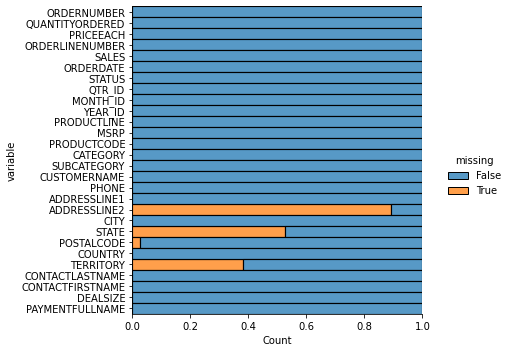

In [26]:
#1.4. Kiểm tra dữ liệu thiếu bằng chart
# Cách 2: Trực quan dữ liệu thiếu vời Seaborn Displt
plt.Figure(figsize=(10,6))
sns.displot(data=df.isna().melt(value_name="missing"),
y="variable",
hue="missing",
multiple="fill",
aspect=1.25)
plt.savefig("my_missing_value_2.png",dpi=100)
#1.4.1. Điền thiếu dữ liệu với dữ liệu định tính
#1.4.1.1. Với dữ liệu biểu diễn dạng chuỗi thì thay bằng Unknown
#1.4.1.2. Với dữ liệu biểu diễn dạng số thì thay bằng 0
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [27]:
#1.1. Đọc dữ liệu
df =pd.read_csv('orginal_sales_data_edit.csv', encoding='UTF8',header=0, delimiter=',')

In [28]:
#1.2. Loại bỏ dòng dữ liệu rỗng
print("Dữ liệu chưa loại bỏ")
df.info
df
#Dữ liệu sau khi loại bỏ
print("Dữ liệu sau khi loại bỏ")
df.dropna(how='all',inplace=True)
df

Dữ liệu chưa loại bỏ
Dữ liệu sau khi loại bỏ


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE,PAYMENTFULLNAME
0,10107,30,95.70,2,2871.00,2/24/2003,Shipped,1,2,2003,...,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small,Yu Kwai
1,10121,34,81.35,5,2765.90,5/7/2003,Shipped,2,5,2003,...,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small,Henriot Paul
2,10134,41,94.74,2,3884.34,7/1/2003,Shipped,3,7,2003,...,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium,DaCunha Daniel
3,10145,45,83.26,6,3746.70,8/25/2003,Shipped,3,8,2003,...,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium,Young Julie
4,10159,49,100.00,14,5205.27,10/10/2003,Shipped,4,10,2003,...,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium,Brown Julie
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,10350,20,100.00,15,2244.40,12/2/2004,Shipped,4,12,2004,...,NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Small,Freyre Diego
2819,10373,29,100.00,1,3978.51,1/31/2005,Shipped,1,1,2005,...,NaN,Oulu,NaN,90110,Finland,EMEA,Koskitalo,Pirkko,Medium,Koskitalo Pirkko
2820,10386,43,100.00,4,5417.57,3/1/2005,Resolved,1,3,2005,...,NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Medium,Freyre Diego
2821,10397,34,62.24,1,2116.16,3/28/2005,Shipped,1,3,2005,...,NaN,Toulouse,NaN,31000,France,EMEA,Roulet,Annette,Small,Roulet Annette


In [29]:
#1.3. Loại bỏ dữ liệu trùng
#2823 dòng
df.drop_duplicates(inplace=True)
df
df.drop_duplicates(subset=['ORDERNUMBER','ORDERDATE'],inplace=True)
df[['ORDERNUMBER','ORDERDATE']]#Kết quả là 2733

,ORDERNUMBER,ORDERDATE
0,10107,2/24/2003
1,10121,5/7/2003
2,10134,7/1/2003
3,10145,8/25/2003
4,10159,10/10/2003
...,...,...
2358,10199,12/1/2003
2532,10397,3/28/2005
2554,10352,12/3/2004
2692,10118,4/21/2003


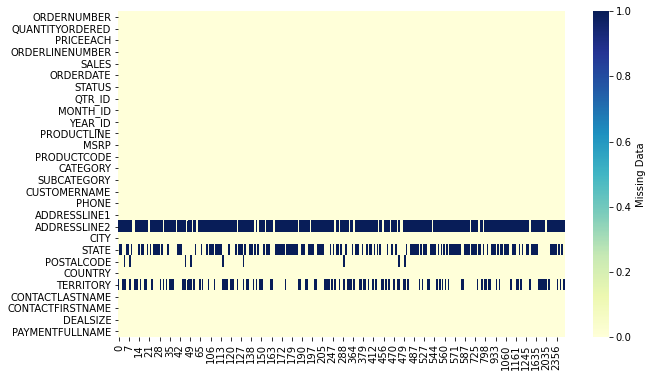

In [30]:
#1.4. Kiểm tra các dữ liệu thiếu bằng chart
#Trực quan dữ liệu thiếu với Seaborn HeatMap, cột màu đậm đang bị thiếu dữ liệu
plt.figure(figsize=(10,6))
sns.heatmap(df.isna().transpose(),cmap="YlGnBu",cbar_kws={'label':'Missing Data'})
plt.savefig("my_missing_value_1.png",dpi=100)

<Figure size 720x432 with 0 Axes>

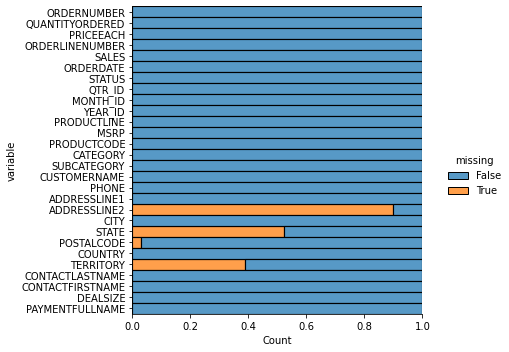

In [31]:
#Cách 2: Trực quan dữ liệu thiếu bằng Seaborn Displot
plt.figure(figsize=(10,6))
sns.displot(data=df.isna().melt(value_name="missing"),y="variable", 
hue="missing",multiple="fill",aspect=1.25)
plt.savefig("my_missing_value_2.png",dpi=100)

In [32]:
#1.4.1. Điền thiếu dữ liệu với dữ liệu định tính
#1.4.1.1. Với dữ liệu biểu diễn dạng chuỗi thì thay dữ liệu thiếu bằng Unknown
#1.4.1.2. Với dữ liệu biểu diễn dạng số thì thay bằng 0 
df['ADDRESSLINE2'].fillna('Unknown', inplace=True)
df['STATE'].fillna('Unknow',inplace=True)
df['TERRITORY'].fillna('Unknown',inplace=True)
df['POSTALCODE'].fillna(0,inplace=True)
print("Xem lại thông tin")
df[['ADDRESSLINE2','STATE','TERRITORY','POSTALCODE']]

Xem lại thông tin


,ADDRESSLINE2,STATE,TERRITORY,POSTALCODE
0,Unknown,NY,Unknown,10022
1,Unknown,Unknow,EMEA,51100
2,Unknown,Unknow,EMEA,75508
3,Unknown,CA,Unknown,90003
4,Unknown,CA,Unknown,0
...,...,...,...,...
2358,Unknown,CA,Unknown,94019
2532,Unknown,Unknow,EMEA,31000
2554,Unknown,MA,Unknown,58339
2692,Unknown,Unknow,EMEA,8022


In [33]:
#1.5. Tách 1 cột thành 2 cột. Sau đó xoá cột bị tách 
df[['PAYMENTLASTNAME', 
'PAYMENTFIRSTNAME']]=df['PAYMENTFULLNAME'].str.split(' ',expand=True)
df=df.drop('PAYMENTFULLNAME',axis=1)
df[['PAYMENTLASTNAME', 'PAYMENTFIRSTNAME']]

,PAYMENTLASTNAME,PAYMENTFIRSTNAME
0,Yu,Kwai
1,Henriot,Paul
2,DaCunha,Daniel
3,Young,Julie
4,Brown,Julie
...,...,...
2358,Thompson,Steve
2532,Roulet,Annette
2554,Taylor,Leslie
2692,Saavedra,Eduardo


In [34]:
#1.6. Lưu dữ liệu thành file mới
df.to_csv('processed_sales_data.csv',sep=',',encoding='utf-8',index=False)

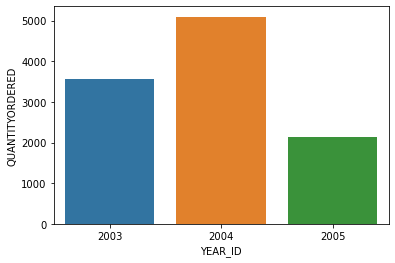

In [ ]:
#1.1.1. Cho biết tổng số lượng sản phẩm bán được của mỗi năm
sns.barplot(x='YEAR_ID',
        y='QUANTITYORDERED',data=df,ci=None,estimator=sum) #thay errorbar -> ci, vì seaborn chưa hỗ trợ
plt.show()

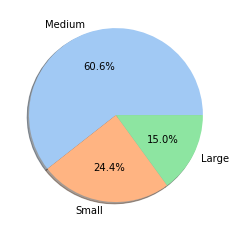

In [36]:
#1.1.2.Có bao nhiêu đơn hàng theo Dealsize
labels=df['DEALSIZE'].value_counts().index
values=df['DEALSIZE'].value_counts().values
colors=sns.color_palette('pastel')
plt.pie(values,labels=labels, colors=colors, autopct='%1.1f%%', shadow=True)
plt.show()

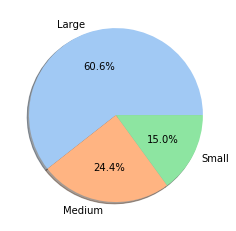

In [37]:
#1.1.3.HOAC SU DUNG NANG CAO VOI NHIEU TUY CHINH TRONG HAM TONG 
#HOP
#1.1.3. Cho biết tỉ lệ giá trị SALES theo DEALSIZE
gb=df.groupby(['DEALSIZE'])['ORDERNUMBER'].agg(['count'])
data=list(gb['count'])
labels=gb.index
colors=sns.color_palette('pastel')
plt.pie(values,labels=labels, colors=colors, autopct='%1.1f%%', shadow=True)
plt.show()

<AxesSubplot:xlabel='ORDERDATE', ylabel='SALES'>

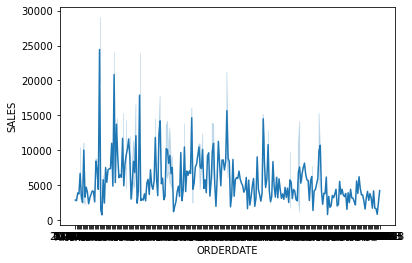

In [38]:
#CHO BIET GIA TRI SALES THEO NGAY
#1.1.7. Cho biết tổng giá trị SALES theo ngày
sns.lineplot(x="ORDERDATE",y="SALES",data=df, estimator=sum)

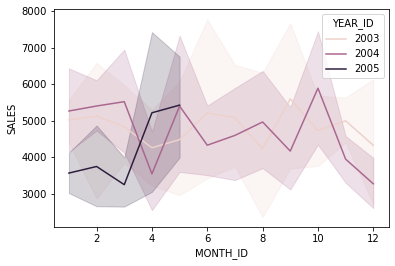

In [39]:
#1.1.8. Cho biết giá trị SALES trung bình theo tháng năm
#default estimator=mean
sns.lineplot(x="MONTH_ID", y="SALES", hue='YEAR_ID',data=df)
plt.show()

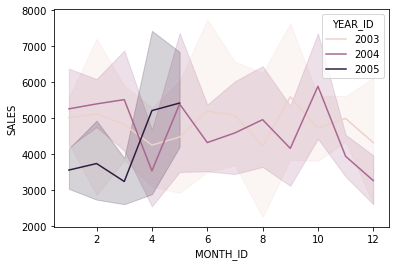

In [40]:
#1.1.8. Cho biết giá trị SALES trung bình theo tháng năm
#default estimator=mean
sns.lineplot(x="MONTH_ID", y="SALES", hue='YEAR_ID',data=df)
plt.show()

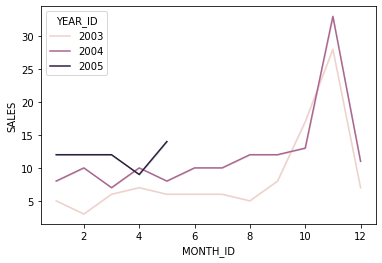

In [41]:
#1.1.8.a Cho biết giá trị SALES theo tháng năm
from numpy import count_nonzero
sns.lineplot ( 
x="MONTH_ID",y="SALES",hue='YEAR_ID',data=df,estimator=count_nonzero)
plt.show()

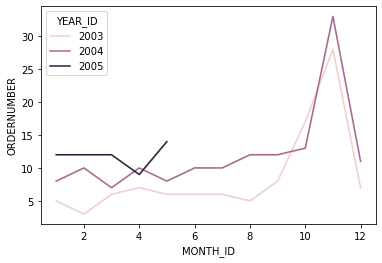

In [42]:
#1.1.9. Cho biết số lượng hoá đơn theo tháng, năm
#Dùng biểu đồ Line
from numpy import count_nonzero
sns.lineplot(x='MONTH_ID',y='ORDERNUMBER',hue='YEAR_ID',data=df,estimator=
count_nonzero)
plt.show()

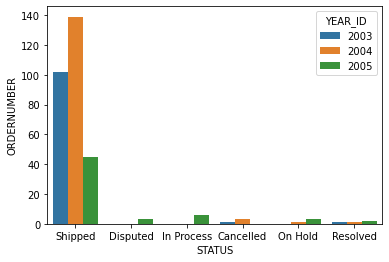

In [44]:
#Cách 2: Dùng barplot
sns.barplot(x='STATUS', y='ORDERNUMBER',hue='YEAR_ID',data=df,
ci=None,estimator=count_nonzero)
plt.show()

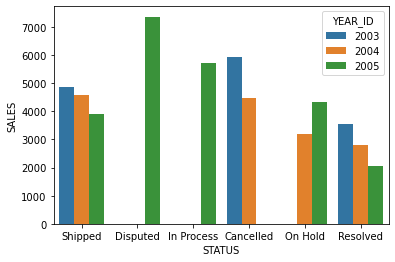

In [46]:
#CHO BIET GIA TRI DON HANG THEO TRANG THAI (STATUS) THEO NHOM 
#CAC NAM(YEAR_ID)
#Dùng biểu đồ barplot
sns.barplot(x='STATUS',y='SALES',hue='YEAR_ID',data=df,ci=None) 
plt.show()

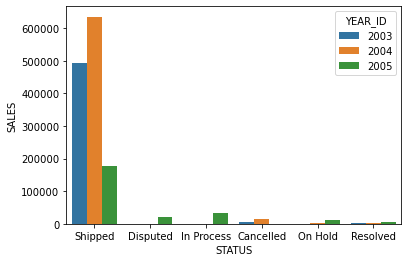

In [49]:
#TONG GIA TRI DON HANG THEO TRANG THAI(STATUS) THEO NHOM CAC 
#NAM (YEAR_ID)
#1.2.1. Cho biết tổng giá trị đơn hàng theo từng trạng thái (STATUS) của mỗi năm
sns.barplot(x='STATUS',y='SALES',hue='YEAR_ID',data=df,ci=None,estimator=sum)
plt.show()

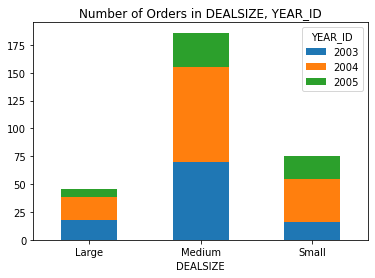

In [50]:
#SO LUONG HOA DON GIUA CAC DEALSIZE THEO YEAR_ID
#1.2.3. Cho biết số lượng hoá đơn giữa các nhóm DEALSIZE theo từng năm YEAR_ID
gb=df.groupby(['DEALSIZE','YEAR_ID'])['ORDERNUMBER'].count().unstack()
gb.plot(kind='bar',stacked=True)
#just add a title and rotate the x-axis labels to the horizontal
plt.title('Number of Orders in DEALSIZE, YEAR_ID')
plt.xticks(rotation=0,ha='center')
plt.show()

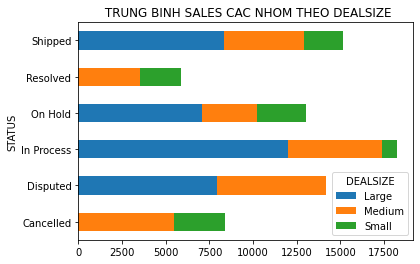

In [51]:
#TRUNG BINH SALES CAC NHO STATUS THEO DEALSIZE
#1.2.4. Cho biết trung bình SALES theo từng STATUS và DEALSIZE
gb=df.groupby(['STATUS','DEALSIZE'])['SALES'].mean().unstack()
gb.plot(kind='barh',stacked=True)
#just add a title and rotate the x-axis labels to the horizontal
plt.title(' TRUNG BINH SALES CAC NHOM THEO DEALSIZE')
plt.xticks(rotation=0,ha='center')
plt.show()

In [52]:
#3. MÔ TẢ DỮ LIỆU
#3.1. Mô tả dữ liệu cột QuantityOrdered
df['QUANTITYORDERED'].describe()

count    307.000000
mean      35.205212
std       10.431550
min        6.000000
25%       27.000000
50%       35.000000
75%       43.000000
max       97.000000
Name: QUANTITYORDERED, dtype: float64

In [53]:
#MO TA DU LIEU CUA QUANTITYORDERED, PRICEEACH, SALES
#3.2. Mô tả dữ liệu của QUANTITYORDERED, PRICEEACH
df[['QUANTITYORDERED','PRICEEACH','SALES']].describe()

,QUANTITYORDERED,PRICEEACH,SALES
count,307.000000,307.000000,307.000000
mean,35.205212,93.351596,4588.486906
std,10.431550,14.912985,2142.986902
min,6.000000,34.910000,553.950000
25%,27.000000,96.915000,3010.500000
50%,35.000000,100.000000,4196.800000
75%,43.000000,100.000000,5855.460000
max,97.000000,100.000000,12001.000000


In [54]:
#MO TA DU LIEU SALES THEO NHOM DEALSIZE
#Mô tả số lượng bán hàng theo từng DEALSIZE
df.groupby('DEALSIZE')['QUANTITYORDERED'].describe()

,count,mean,std,min,25%,50%,75%,max
DEALSIZE,,,,,,,,
Large,46.0,44.739130,11.227812,29.0,38.0,44.0,47.0,97.0
Medium,186.0,35.672043,8.395943,20.0,30.0,36.0,42.0,55.0
Small,75.0,28.200000,9.502489,6.0,22.0,25.0,33.0,49.0


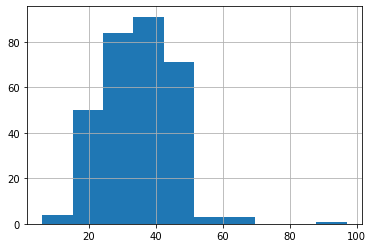

In [55]:
#PHẦN 4: KHAI THÁC SỰ PHÂN PHỐI DỮ LIỆU, CHỈ DÙNG TRÊN BIẾN ĐỊNH 
#LƯỢNG
#4.1. VE BIEU DO HISTOGRAM CUA QUANTITYORDERED
df['QUANTITYORDERED'].hist()
plt.show()

In [ ]:
#HOAC NANG CAO HON VOI NHIEU TUY CHON
# sns displot(df,x="QUANTITYORDERED",kind="kde")
# plt.show()

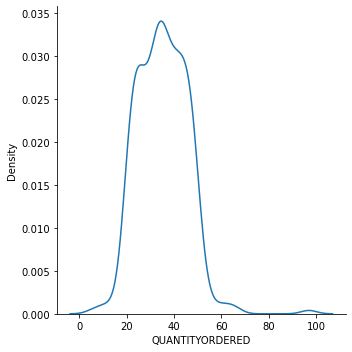

In [56]:
#HOAC NANG CAO HON VOI NHIEU TUY CHON
sns.displot(df,x="QUANTITYORDERED",kind="kde")
plt.show()